In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_moons
x, y=make_moons(n_samples=500, noise=0.4, random_state=1)

In [3]:
def plot_dataset(x, y, axes):
    plt.plot(x[y==0,0],x[y==0,1],'ro',markersize=3)
    plt.plot(x[y==1,0],x[y==1,1],'g^',markersize=3)
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18)

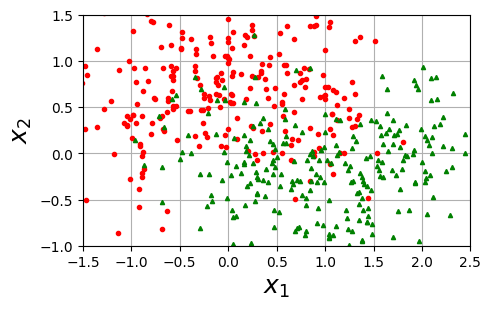

In [4]:
plt.figure(figsize=(5,3))
plot_dataset(x,y,[-1.5,2.5,-1,1.5])
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x, y, random_state=1)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

log_clf=LogisticRegression(solver='lbfgs',random_state=1)
svm_clf=SVC(random_state=1)
tree_clf=DecisionTreeClassifier(random_state=1)

In [7]:
from sklearn.ensemble import VotingClassifier

hard_clf=VotingClassifier([('lr',log_clf),('svm',svm_clf),('tree',tree_clf)],voting='hard')

hard_clf.fit(x_train,y_train)
hard_clf.predict(x_test[:5])

array([0, 1, 1, 1, 1])

In [8]:
for clf in (log_clf,svm_clf,tree_clf,hard_clf):
    clf.fit(x_train,y_train)
    print(clf.__class__.__name__,':',clf.score(x_test,y_test))

LogisticRegression : 0.8
SVC : 0.816
DecisionTreeClassifier : 0.792
VotingClassifier : 0.824


In [9]:
svm_clf_prob=SVC(probability=True,random_state=1)

soft_clf=VotingClassifier([('lr',log_clf),('svm',svm_clf_prob),('tree',tree_clf)],voting='soft')

soft_clf.fit(x_train,y_train)
soft_clf.predict(x_test[:5])

array([1, 1, 1, 1, 1])

In [10]:
for clf in (log_clf,svm_clf_prob,tree_clf,soft_clf):
    clf.fit(x_train,y_train)
    print(clf.__class__.__name__,':',clf.score(x_test,y_test))

LogisticRegression : 0.8
SVC : 0.816
DecisionTreeClassifier : 0.792
VotingClassifier : 0.816


In [17]:
np.random.seed(1)

m=500
x=10*np.random.rand(m,1)-6
y=(10+6*x+5*x**2+30*np.random.rand(m,1)).ravel()

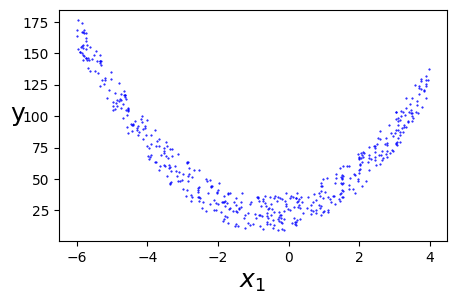

In [18]:
plt.figure(figsize=(5,3))
plt.plot(x,y,'b.',markersize=1)
plt.xlabel('$x_1$', fontsize=18)
plt.ylabel("y", rotation=0, fontsize=18)
plt.show()

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

lin_reg=LinearRegression()
svm_reg=SVR()
tree_reg=DecisionTreeRegressor(random_state=1)

In [20]:
from sklearn.ensemble import VotingRegressor

en_reg=VotingRegressor([('lr',lin_reg),('svm',svm_reg),('tree',tree_reg)])

en_reg.fit(x_train,y_train)
en_reg.predict(x_test[:3])

array([0.56927633, 0.49881337, 0.86831107])

In [21]:
for clf in (lin_reg,svm_reg,tree_reg,en_reg):
    clf.fit(x_train,y_train)
    print(clf.__class__.__name__,':',clf.score(x_test,y_test))

LinearRegression : 0.4199235040893753
SVR : 0.4400181256211858
DecisionTreeRegressor : 0.14383561643835596
VotingRegressor : 0.4473256610918679
